Project: Multi-Level Revenue Forecasting and Demand Analysis for Resort Operations

Author: Ashek Alahi  
Date: May 2026  
Tools: Python, SQL, Excel  

Objective:
The objective of this project is to develop a multi-level forecasting system for resort operations by analyzing seasonal demand patterns across hotel, ski, and golf services.


 Project Workflow:

1. Data Collection & Cleaning (Excel)
2. Data Storage (SQL Database)
3. Data Extraction & Loading (Python)
4. Exploratory Data Analysis (EDA)
5. Forecasting Model Development
6. Model Evaluation & Comparison
7. Business Insights & Recommendations

Cunnection cell

In [1]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Hridoy123",
    database="resort_revenue"
)

cursor = conn.cursor()

print("Database connected successfully")

Database connected successfully


In [2]:
import pandas as pd

df = pd.read_sql("SELECT * FROM revenue_analysis", conn)



C:\Users\Administrator\AppData\Local\Temp\ipykernel_10644\3644701527.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM revenue_analysis", conn)


In [3]:
import pandas as pd

df = pd.read_sql("SELECT * FROM revenue_analysis", conn)

# STEP 1: standardize column names (optional but recommended)
df.columns = df.columns.str.strip()

# STEP 2: fix date
df['Date'] = pd.to_datetime(df['Date'])

# STEP 3: sort data
df = df.sort_values('Date')

# STEP 4: create ALL time features ONCE (never repeat later)
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Year'] = df['Date'].dt.year
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['IsWeekend'] = df['DayOfWeek'].isin([5,6]).astype(int)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10644\3036756577.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM revenue_analysis", conn)


SQL Database Integration

CREATE TABLE revenue_analysis (
    Date DATE,
    Department VARCHAR(20),
    Revenue FLOAT
);

SELECT *
FROM revenue_analysis;

All revenue values are expressed in Million Japanese Yen (JPY).

In [4]:
import matplotlib.pyplot as plt

A. EXPLORATORY ANALYSIS:
   1. Monthly Total revenue
   2. Monthly Revenue by Department
   3. Daily Revenue Trend
   4. Daily Revenue by Department
   5. Average Monthly Revenue by Department
   6. Weekend vs Weekday Revenue

 1. Monthly Total revenue

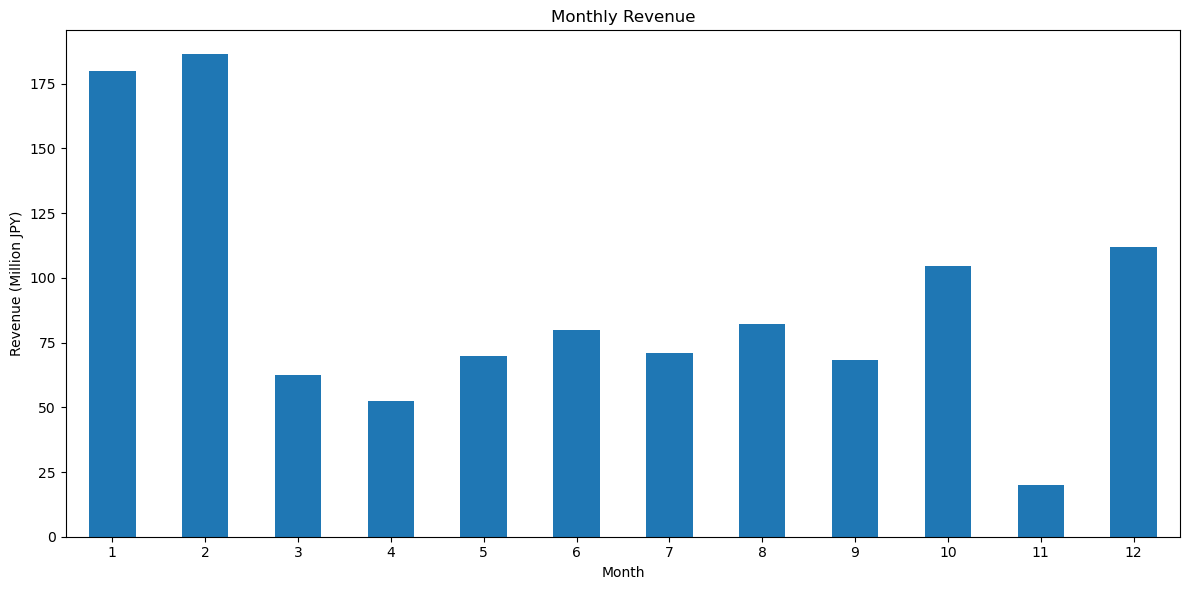

In [5]:
import matplotlib.pyplot as plt

# STEP 1: create monthly properly
monthly = df.groupby('Month')['Revenue'].sum()

# STEP 2: convert safely
monthly = monthly.astype(float)
monthly_million = monthly / 1_000_000

# STEP 3: (ONLY if index is datetime)
# monthly_million.index = monthly_million.index.strftime('%b')

ax = monthly_million.plot(
    kind='bar',
    figsize=(12,6),
    title="Monthly Revenue"
)

plt.xlabel("Month")
plt.ylabel("Revenue (Million JPY)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show() 

2. Monthly Revenue by Department

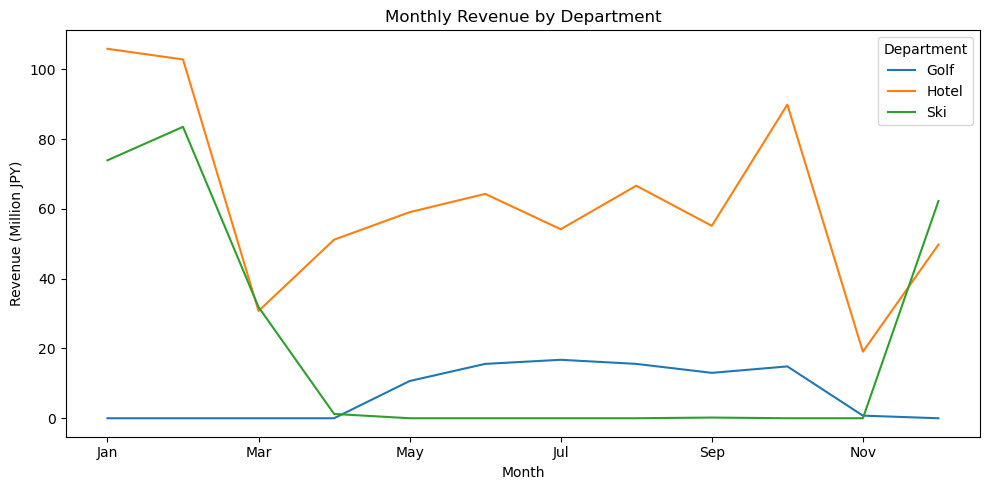

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# FIX: convert to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create month column
df['month'] = df['Date'].dt.strftime('%b')

# Group data
monthly_dept = df.groupby(['month', 'Department'])['Revenue'].sum().unstack()

# Order months correctly
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_dept = monthly_dept.reindex(month_order)

# Convert to Million Yen
monthly_dept_million = monthly_dept / 1_000_000

# Plot
monthly_dept_million.plot(figsize=(10,5), title="Monthly Revenue by Department")

plt.xlabel("Month")
plt.ylabel("Revenue (Million JPY)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

 3. Daily Revenue Trend

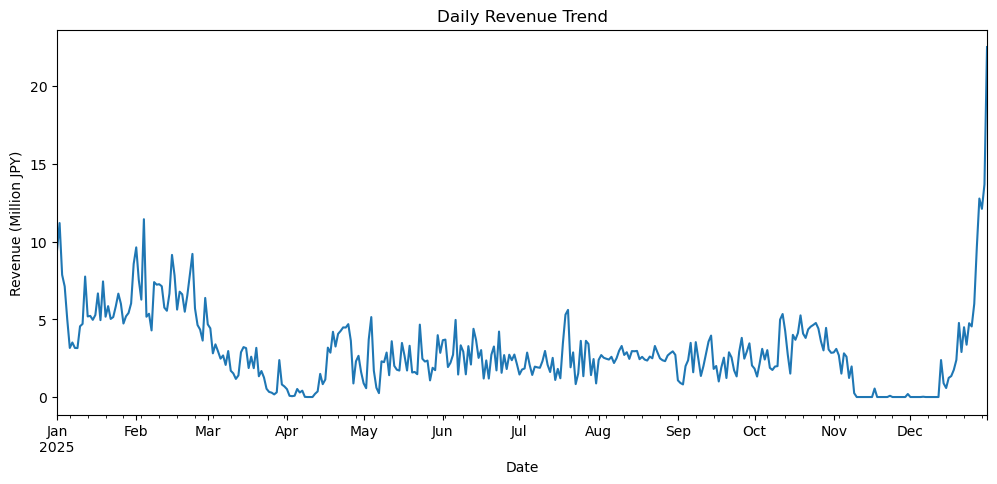

In [7]:
daily = df.groupby('Date')['Revenue'].sum() / 1_000_000

daily.plot(figsize=(12,5), title="Daily Revenue Trend")

import matplotlib.pyplot as plt
plt.ylabel("Revenue (Million JPY)")
plt.xlabel("Date")
plt.show()

4. Daily Revenue by Department

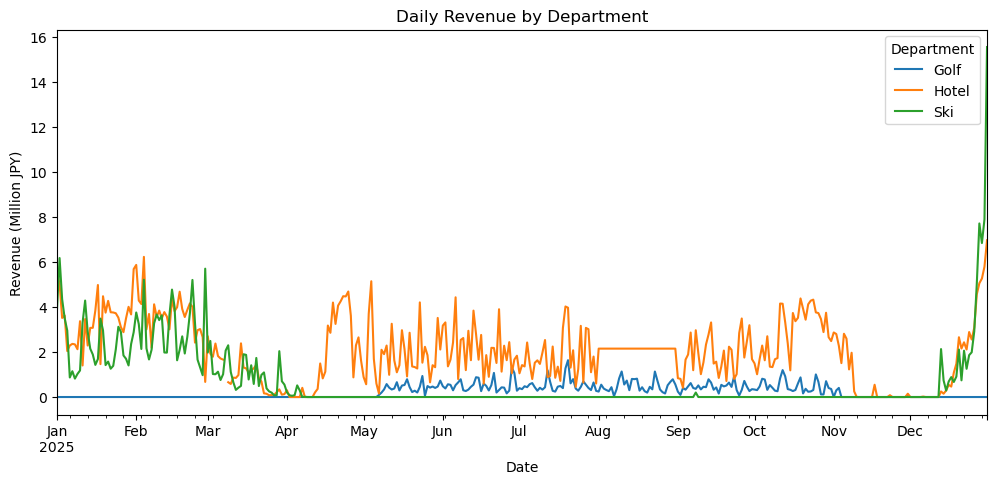

In [8]:
daily_dept = df.groupby(['Date','Department'])['Revenue'].sum().unstack() / 1_000_000

daily_dept.plot(figsize=(12,5), title="Daily Revenue by Department")

plt.xlabel("Date")
plt.ylabel("Revenue (Million JPY)")
plt.show()

   5. Average Monthly Revenue by Department

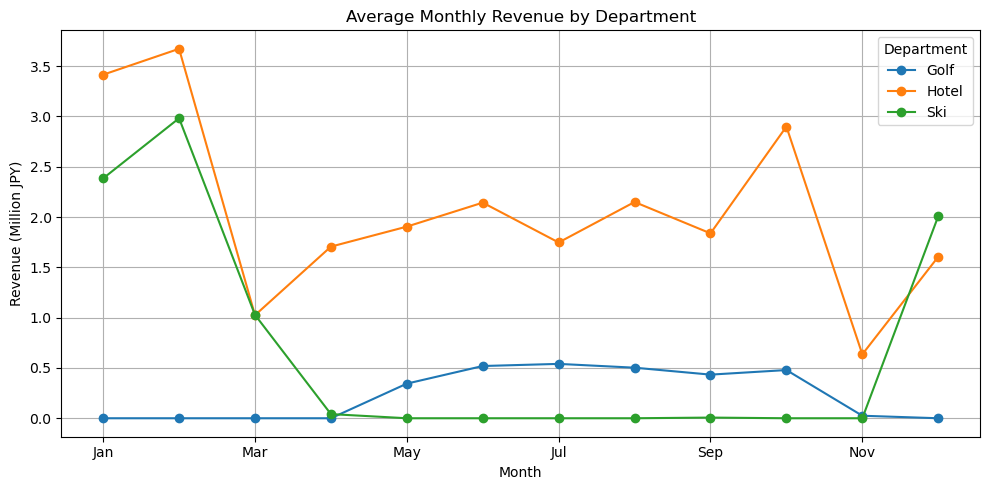

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create month (same format as your working code)
df['month'] = df['Date'].dt.strftime('%b')

# Group by MONTH + DEPARTMENT (MEAN instead of SUM)
avg_monthly_dept = df.groupby(['month', 'Department'])['Revenue'].mean().unstack()

# Correct month order
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

avg_monthly_dept = avg_monthly_dept.reindex(month_order)

# Convert to million
avg_monthly_dept = avg_monthly_dept / 1_000_000

# Plot
avg_monthly_dept.plot(figsize=(10,5), marker='o', title="Average Monthly Revenue by Department")

plt.xlabel("Month")
plt.ylabel("Revenue (Million JPY)")
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()

plt.show()

 6. Weekend vs Weekday Revenue

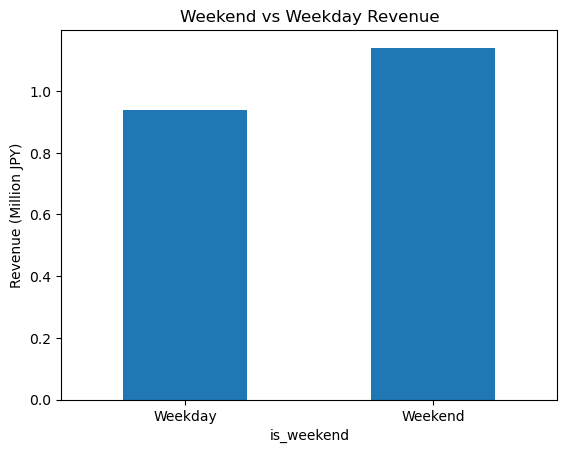

In [10]:
df['day_of_week'] = df['Date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5,6])

weekend_analysis = df.groupby('is_weekend')['Revenue'].mean() / 1_000_000

weekend_analysis.plot(kind='bar', title="Weekend vs Weekday Revenue")

plt.ylabel("Revenue (Million JPY)")
plt.xticks([0,1], ["Weekday","Weekend"], rotation=0)
plt.show()

In [11]:
top_days = df.sort_values(by='Revenue', ascending=False).head(10)

top_days['revenue_million'] = top_days['Revenue'] / 1_000_000

top_days[['Date','Department','revenue_million']]

,Date,Department,revenue_million
1092,2025-12-31,Ski,15.542858
1089,2025-12-30,Ski,7.892841
1083,2025-12-28,Ski,7.708188
1091,2025-12-31,Hotel,6.962575
1086,2025-12-29,Ski,6.837337
102,2025-02-04,Hotel,6.224135
4,2025-01-02,Ski,6.172501
93,2025-02-01,Hotel,5.866701
1088,2025-12-30,Hotel,5.787941
175,2025-02-28,Ski,5.699805


B.TIME SERIES DECOMPOSITION:

     1. Trend 
     2. Seasonality 
     3. Residual 

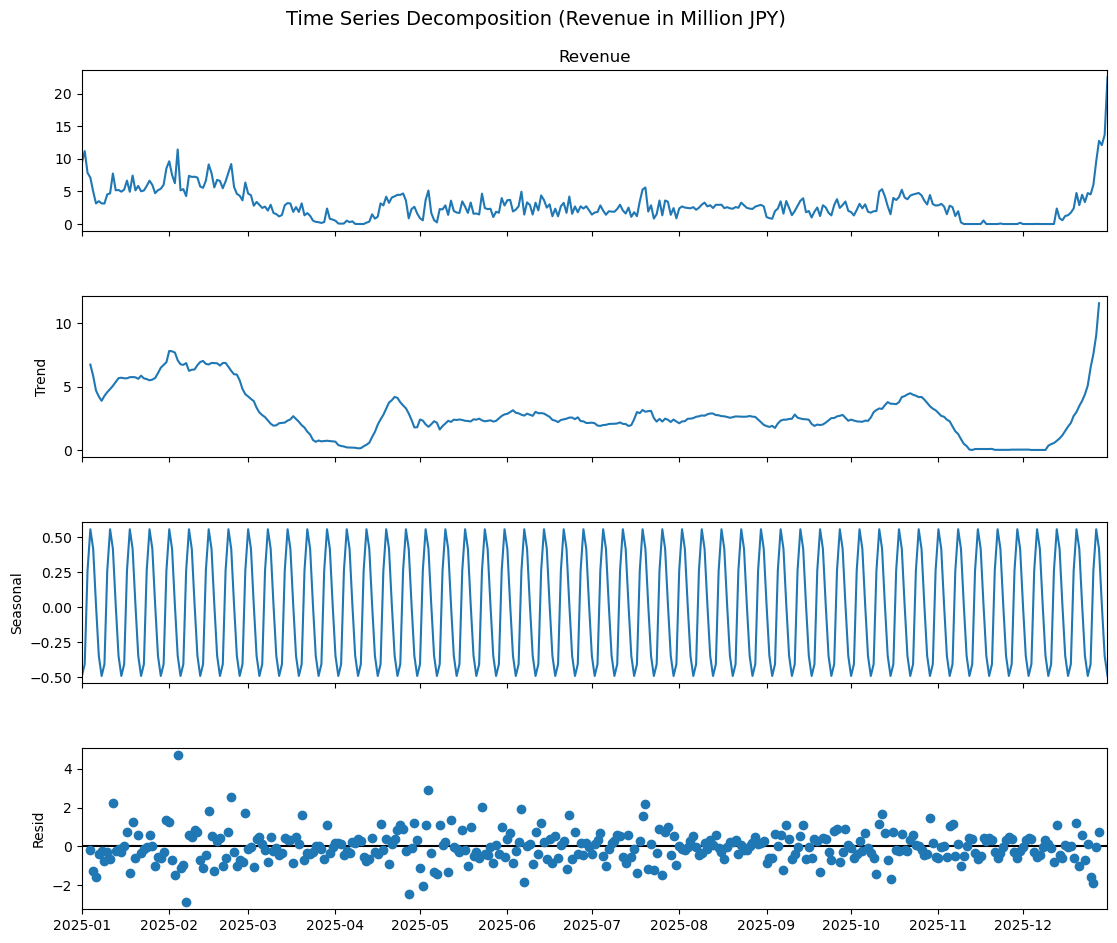

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import pandas as pd

# Aggregate daily revenue (Million JPY)
daily = df.groupby('Date')['Revenue'].sum() / 1_000_000

# Convert index to datetime
daily.index = pd.to_datetime(daily.index)

# Set daily frequency
daily = daily.asfreq('D')

# Decomposition
decomposition = seasonal_decompose(daily, model='additive')

# Plot with better spacing
fig = decomposition.plot()
fig.set_size_inches(12, 10)  # Bigger figure = less overlap

# Adjust layout to prevent overlap
plt.subplots_adjust(top=0.92, hspace=0.4)

# Clean main title placement
plt.suptitle("Time Series Decomposition (Revenue in Million JPY)", fontsize=14)

plt.show()

C. FEATURE ENGINEERING:

    1. Lag variables (yesterday revenue) 
    2. Rolling average (7-day mean) 
    3. Holiday flags
   

In [13]:
df = df.sort_values('Date')

df['Lag_1'] = df['Revenue'].shift(1)

In [14]:
!pip install holidays

In [15]:
import holidays

jp_holidays = holidays.Japan()

df['IsHoliday'] = df['Date'].isin(jp_holidays).astype(int)

In [16]:
df = df.sort_values('Date')
df['Date'] = pd.to_datetime(df['Date'])

df['Lag_1'] = df['Revenue'].shift(1)
df['Rolling_7'] = df['Revenue'].rolling(7).mean()
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['IsWeekend'] = df['DayOfWeek'].isin([5,6]).astype(int)
df['Month'] = df['Date'].dt.month

import holidays
jp_holidays = holidays.Japan()
df['IsHoliday'] = df['Date'].isin(jp_holidays).astype(int)

df = df.dropna()

In [17]:
df = df.dropna()

In [18]:
df.head()

,Date,Department,Revenue,Month,Month_Name,Year,DayOfWeek,IsWeekend,month,day_of_week,is_weekend,Lag_1,IsHoliday,Rolling_7
6,2025-01-03,Hotel,3512557,1,Jan,2025,4,0,Jan,4,False,0.0,0,3.447347e+06
7,2025-01-03,Ski,4343507,1,Jan,2025,4,0,Jan,4,False,3512557.0,0,3.278302e+06
8,2025-01-03,Golf,0,1,Jan,2025,4,0,Jan,4,False,4343507.0,0,2.720414e+06
9,2025-01-04,Hotel,3619282,1,Jan,2025,5,1,Jan,5,True,0.0,0,3.237455e+06
10,2025-01-04,Ski,3491097,1,Jan,2025,5,1,Jan,5,True,3619282.0,0,3.019849e+06


In [19]:
daily_total = df.groupby('Date')['Revenue'].sum().reset_index()

In [20]:
daily_total['Date'] = pd.to_datetime(daily_total['Date'])

In [21]:
daily_total = daily_total.sort_values('Date')

In [22]:
daily_total.set_index('Date', inplace=True)

In [23]:
daily_total.head()

,Revenue
Date,
2025-01-03,7856064
2025-01-04,7110379
2025-01-05,4992600
2025-01-06,3154987
2025-01-07,3506418


In [24]:
train = daily_total.iloc[:-30]
test = daily_total.iloc[-30:]

In [25]:
print(train.shape)
print(test.shape)

(333, 1)
(30, 1)


In [26]:
forecast_ma = [train['Revenue'].tail(7).mean()] * len(test)

In [27]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model_es = ExponentialSmoothing(
    train['Revenue'],
    trend='add',
    seasonal='add',
    seasonal_periods=7
).fit()

es_pred = model_es.forecast(len(test))

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [28]:
daily_total['lag_1'] = daily_total['Revenue'].shift(1)

daily_total['rolling_7'] = (
    daily_total['Revenue']
    .rolling(window=7)
    .mean()
)

daily_total['is_weekend'] = (
    daily_total.index.dayofweek >= 5
).astype(int)

In [29]:
daily_total = daily_total.dropna()

In [30]:
train = daily_total.iloc[:-30]
test = daily_total.iloc[-30:]

In [31]:
from sklearn.linear_model import LinearRegression

features = ['lag_1', 'rolling_7', 'is_weekend']

X_train = train[features]
y_train = train['Revenue']

X_test = test[features]
y_test = test['Revenue']

In [32]:
model_lr = LinearRegression()

model_lr.fit(X_train, y_train)

lr_pred = model_lr.predict(X_test)

In [33]:
from sklearn.linear_model import LinearRegression

features = ['lag_1', 'rolling_7', 'is_weekend']

X_train = train[features]
y_train = train['Revenue']

X_test = test[features]

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

lr_pred = model_lr.predict(X_test)

In [34]:
from sklearn.linear_model import LinearRegression

features = ['lag_1', 'rolling_7', 'is_weekend']

X_train = train[features]
y_train = train['Revenue']

X_test = test[features]

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

lr_pred = model_lr.predict(X_test)

In [35]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae_es = mean_absolute_error(test['Revenue'], es_pred)

rmse_es = np.sqrt(
    mean_squared_error(test['Revenue'], es_pred)
)

mape_es = np.mean(
    np.abs((test['Revenue'] - es_pred) / test['Revenue'])
) * 100

In [36]:
print(es_pred)

2025-12-02   -573903.201081
2025-12-03   -533943.866498
2025-12-04   -425364.446978
2025-12-05   -175213.581821
2025-12-06    160590.460924
2025-12-07    184511.711544
2025-12-08    -43556.309258
2025-12-09   -635138.934190
2025-12-10   -595179.599607
2025-12-11   -486600.180087
2025-12-12   -236449.314930
2025-12-13     99354.727816
2025-12-14    123275.978435
2025-12-15   -104792.042366
2025-12-16   -696374.667299
2025-12-17   -656415.332715
2025-12-18   -547835.913196
2025-12-19   -297685.048038
2025-12-20     38118.994707
2025-12-21     62040.245326
2025-12-22   -166027.775475
2025-12-23   -757610.400408
2025-12-24   -717651.065824
2025-12-25   -609071.646304
2025-12-26   -358920.781147
2025-12-27    -23116.738402
2025-12-28       804.512217
2025-12-29   -227263.508584
2025-12-30   -818846.133516
2025-12-31   -778886.798933
Freq: D, dtype: float64


D. Models:
   1. Exponential Smoothing forecast
   2. Moving Average Baseline Forecast
   3. ARIMA Revenue Forecast
   4. Regression-Based Revenue Forecast
   5. Hierarchical Monthly Revenue Forecast

   1. Exponential Smoothing forecast

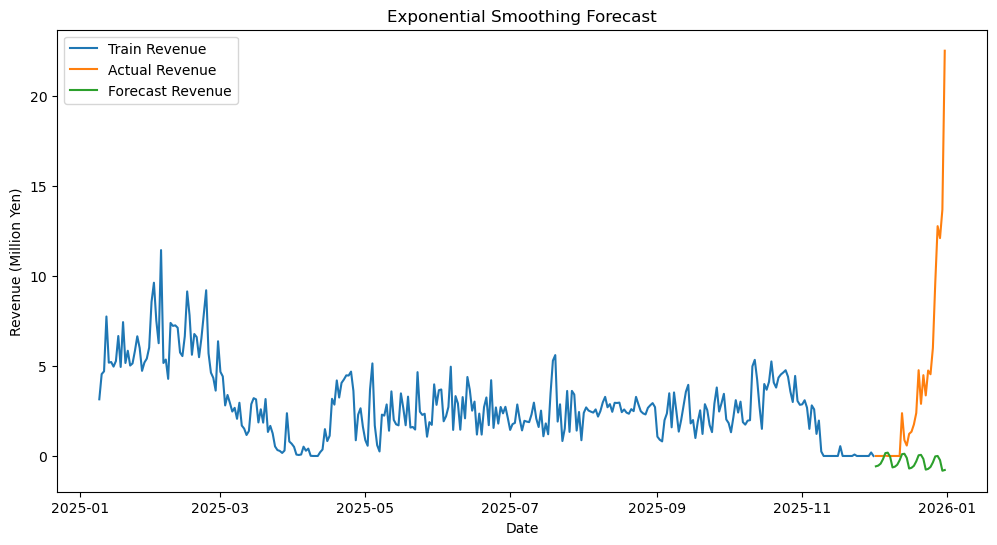

In [37]:
import matplotlib.pyplot as plt

# Convert revenue to million yen
train_million = train['Revenue'] / 1_000_000
test_million = test['Revenue'] / 1_000_000
es_pred_million = es_pred / 1_000_000

plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train_million,
    label='Train Revenue'
)

plt.plot(
    test.index,
    test_million,
    label='Actual Revenue'
)

plt.plot(
    test.index,
    es_pred_million,
    label='Forecast Revenue'
)

plt.title(
    'Exponential Smoothing Forecast'
)

plt.xlabel('Date')

plt.ylabel('Revenue (Million Yen)')

plt.legend()

plt.show()

2. Moving Average Baseline Forecast

In [38]:
window = 7

In [39]:
train_ma = train['Revenue'].rolling(window=window).mean()

In [40]:
last_ma = train_ma.dropna().iloc[-1]

In [41]:
forecast_ma = [last_ma] * len(test)

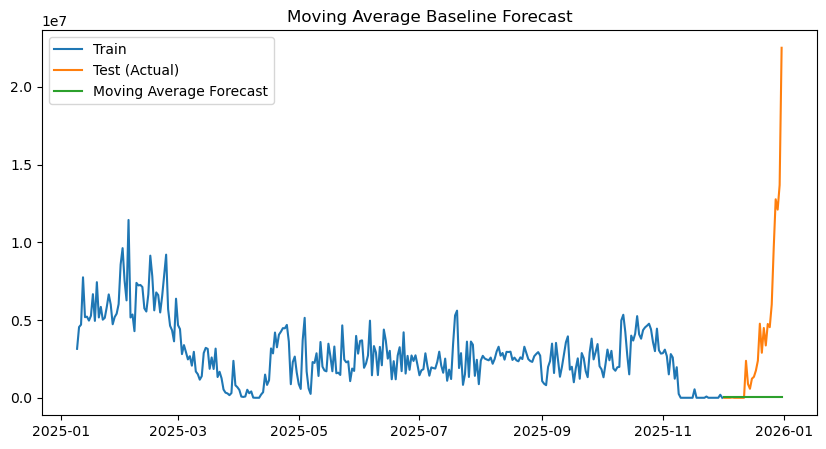

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(train.index, train['Revenue'], label='Train')
plt.plot(test.index, test['Revenue'], label='Test (Actual)')
plt.plot(test.index, forecast_ma, label='Moving Average Forecast')

plt.legend()
plt.title('Moving Average Baseline Forecast')
plt.show()

3. ARIMA Forecasting

In [43]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae_ma = mean_absolute_error(
    test['Revenue'],
    forecast_ma
)

rmse_ma = np.sqrt(
    mean_squared_error(
        test['Revenue'],
        forecast_ma
    )
)

mape_ma = np.mean(
    np.abs(
        (test['Revenue'] - forecast_ma)
        / test['Revenue']
    )
) * 100

print("MAE:", mae_ma)
print("RMSE:", rmse_ma)
print("MAPE:", mape_ma)

MAE: 3725199.761904762
RMSE: 6453614.346070579
MAPE: inf


In [44]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae_es = mean_absolute_error(
    test['Revenue'],
    es_pred
)

rmse_es = np.sqrt(
    mean_squared_error(
        test['Revenue'],
        es_pred
    )
)

mape_es = np.mean(
    np.abs(
        (test['Revenue'] - es_pred)
        / test['Revenue']
    )
) * 100

print("MAE:", mae_es)
print("RMSE:", rmse_es)
print("MAPE:", mape_es)

MAE: 4082174.300020797
RMSE: 6718213.788351183
MAPE: inf


In [45]:
from statsmodels.tsa.arima.model import ARIMA

In [46]:
model_arima = ARIMA(
    train['Revenue'],
    order=(1,1,1)
)

model_arima_fit = model_arima.fit()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [47]:
arima_pred = model_arima_fit.forecast(
    steps=len(test)
)

In [48]:
print(arima_pred)

2025-12-02    29331.674130
2025-12-03    36560.141699
2025-12-04    38341.517803
2025-12-05    38780.518295
2025-12-06    38888.705125
2025-12-07    38915.366575
2025-12-08    38921.936996
2025-12-09    38923.556203
2025-12-10    38923.955239
2025-12-11    38924.053577
2025-12-12    38924.077812
2025-12-13    38924.083784
2025-12-14    38924.085256
2025-12-15    38924.085618
2025-12-16    38924.085708
2025-12-17    38924.085730
2025-12-18    38924.085735
2025-12-19    38924.085737
2025-12-20    38924.085737
2025-12-21    38924.085737
2025-12-22    38924.085737
2025-12-23    38924.085737
2025-12-24    38924.085737
2025-12-25    38924.085737
2025-12-26    38924.085737
2025-12-27    38924.085737
2025-12-28    38924.085737
2025-12-29    38924.085737
2025-12-30    38924.085737
2025-12-31    38924.085737
Freq: D, Name: predicted_mean, dtype: float64


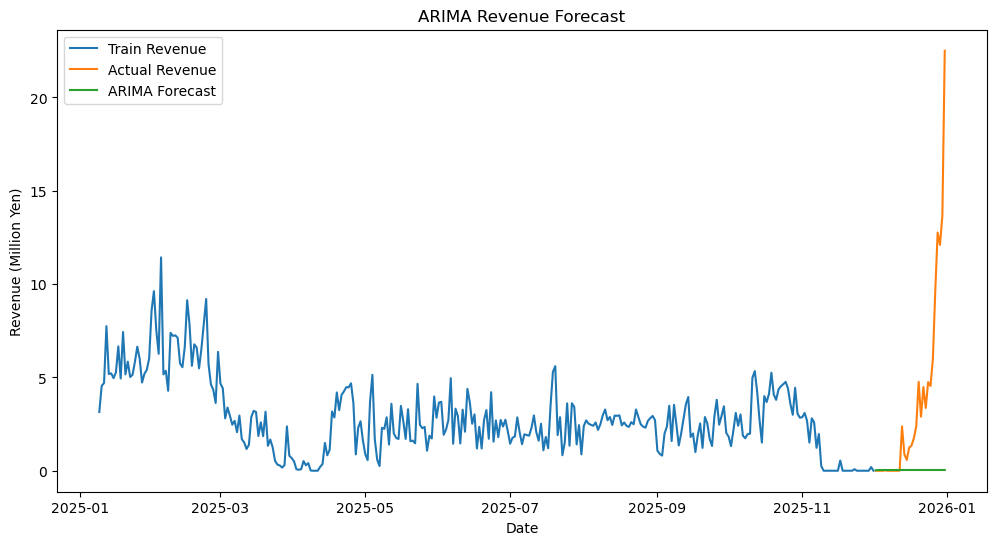

In [49]:
import matplotlib.pyplot as plt

# Convert revenue to million yen
train_million = train['Revenue'] / 1_000_000
test_million = test['Revenue'] / 1_000_000
arima_pred_million = arima_pred / 1_000_000

plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train_million,
    label='Train Revenue'
)

plt.plot(
    test.index,
    test_million,
    label='Actual Revenue'
)

plt.plot(
    test.index,
    arima_pred_million,
    label='ARIMA Forecast'
)

plt.title('ARIMA Revenue Forecast')

plt.xlabel('Date')

plt.ylabel('Revenue (Million Yen)')

plt.legend()

plt.show()

4. Regression-Based Revenue Forecast

In [50]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae_arima = mean_absolute_error(
    test['Revenue'],
    arima_pred
)

rmse_arima = np.sqrt(
    mean_squared_error(
        test['Revenue'],
        arima_pred
    )
)

mape_arima = np.mean(
    np.abs(
        (test['Revenue'] - arima_pred)
        / test['Revenue']
    )
) * 100

print("MAE:", mae_arima)
print("RMSE:", rmse_arima)
print("MAPE:", mape_arima)

MAE: 3721791.7292347243
RMSE: 6447192.972180175
MAPE: inf


In [51]:
daily_total['Lag_1'] = daily_total['Revenue'].shift(1)

daily_total['Rolling_7'] = (
    daily_total['Revenue']
    .rolling(window=7)
    .mean()
)

daily_total['Weekend'] = (
    daily_total.index.dayofweek >= 5
).astype(int)

daily_total['Month'] = daily_total.index.month

In [52]:
from sklearn.linear_model import LinearRegression

X_train = train[features]

y_train = train['Revenue']

X_test = test[features]

y_test = test['Revenue']

model_lr = LinearRegression()

model_lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


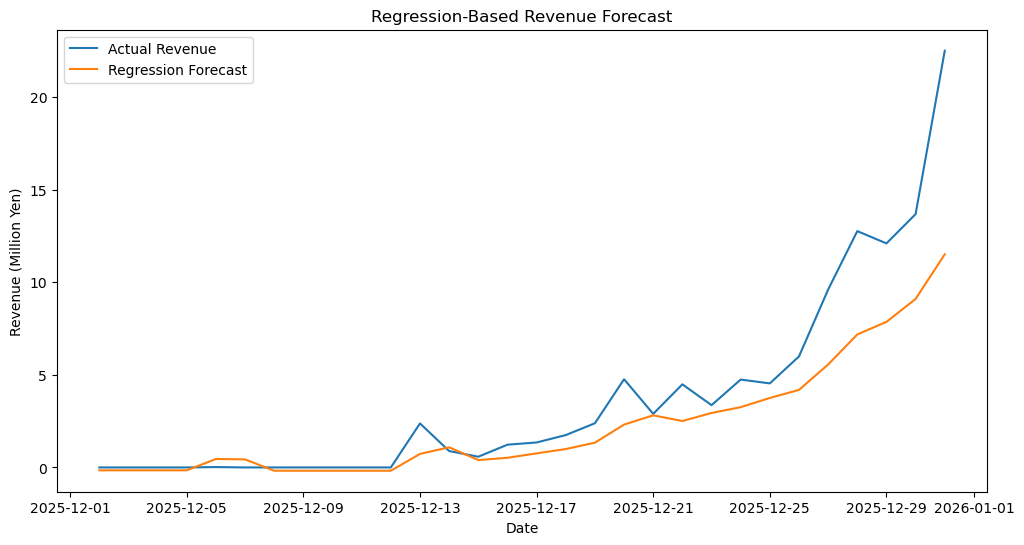

In [53]:
import matplotlib.pyplot as plt

# Convert revenue to million yen
y_test_million = y_test / 1_000_000
lr_pred_million = lr_pred / 1_000_000

plt.figure(figsize=(12,6))

plt.plot(
    test.index,
    y_test_million,
    label='Actual Revenue'
)

plt.plot(
    test.index,
    lr_pred_million,
    label='Regression Forecast'
)

plt.title('Regression-Based Revenue Forecast')

plt.xlabel('Date')

plt.ylabel('Revenue (Million Yen)')

plt.legend()

plt.show()

5. Hierarchical Monthly Revenue Forecast

In [54]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae_lr = mean_absolute_error(
    y_test,
    lr_pred
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

mape_lr = np.mean(
    np.abs(
        (y_test - lr_pred)
        / y_test
    )
) * 100

print("MAE:", mae_lr)

print("RMSE:", rmse_lr)

print("MAPE:", mape_lr)

MAE: 1532132.5145019337
RMSE: 2765574.487833408
MAPE: inf


In [55]:
df['Revenue'] = df['Revenue'] / 1000000

In [56]:
hotel_df = df[
    df['Department'] == 'Hotel'
]

In [57]:
ski_df = df[
    df['Department'] == 'Ski'
]

In [58]:
golf_df = df[
    df['Department'] == 'Golf'
]

Hierarchical Forecasting : 

“Department-level forecasting revealed structurally different operational cycles across resort services. Ski operations concentrated heavily in winter months, while golf operations exhibited strong summer dependency, creating sparse off-season revenue periods.”

In [59]:
df['Date'] = pd.to_datetime(df['Date'])

In [60]:
df['Month_Date'] = df['Date'].dt.to_period('M')

In [61]:
df['Month_Date'] = df['Date'].dt.to_period('M')

In [62]:
monthly_df = df.groupby(
    ['Month_Date', 'Department']
)['Revenue'].sum().reset_index()

In [63]:
monthly_df.head()

,Month_Date,Department,Revenue
0,2025-01,Golf,0.000000
1,2025-01,Hotel,95.318243
2,2025-01,Ski,63.834573
3,2025-02,Golf,0.000000
4,2025-02,Hotel,102.817338


In [64]:
hotel_monthly = monthly_df[
    monthly_df['Department'] == 'Hotel'
]

In [65]:
ski_monthly = monthly_df[
    monthly_df['Department'] == 'Ski'
]

In [66]:
golf_monthly = monthly_df[
    monthly_df['Department'] == 'Golf'
]

In [67]:
hotel_monthly = hotel_monthly.set_index(
    'Month_Date'
)

hotel_monthly.index = (
    hotel_monthly.index.to_timestamp()
)

In [68]:
ski_monthly = ski_monthly.set_index(
    'Month_Date'
)

ski_monthly.index = (
    ski_monthly.index.to_timestamp()
)

In [69]:
golf_monthly = golf_monthly.set_index(
    'Month_Date'
)

golf_monthly.index = (
    golf_monthly.index.to_timestamp()
)

In [70]:
hotel_train = hotel_monthly.iloc[:-3]

hotel_test = hotel_monthly.iloc[-3:]

In [71]:
ski_train = ski_monthly.iloc[:-3]

In [72]:
golf_train = golf_monthly.iloc[:-3]

golf_test = golf_monthly.iloc[-3:]

In [73]:
from statsmodels.tsa.arima.model import ARIMA

hotel_model = ARIMA(
    hotel_train['Revenue'],
    order=(1,1,1)
)

hotel_fit = hotel_model.fit()

hotel_forecast = hotel_fit.forecast(
    steps=len(hotel_test)
)

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [74]:
ski_df['Date'] = pd.to_datetime(ski_df['Date'])
ski_df = ski_df.sort_values('Date')
ski_df = ski_df.set_index('Date')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10644\2265913025.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ski_df['Date'] = pd.to_datetime(ski_df['Date'])


In [75]:
ski_df = ski_df.sort_index()
ski_df = ski_df.asfreq('D')

In [76]:
train_size = int(len(ski_df) * 0.8)

ski_train = ski_df.iloc[:train_size]
ski_test = ski_df.iloc[train_size:]

In [77]:
ski_model = ARIMA(
    ski_train['Revenue'],
    order=(1,1,1)
)

ski_fit = ski_model.fit()

ski_forecast = ski_fit.forecast(
    steps=len(ski_test)
)

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [78]:
golf_model = ARIMA(
    golf_train['Revenue'],
    order=(2,1,2)
)

golf_fit = golf_model.fit()

golf_forecast = golf_fit.forecast(
    steps=len(golf_test)
)

In [79]:
total_forecast = (
    hotel_forecast
    + ski_forecast
    + golf_forecast
)

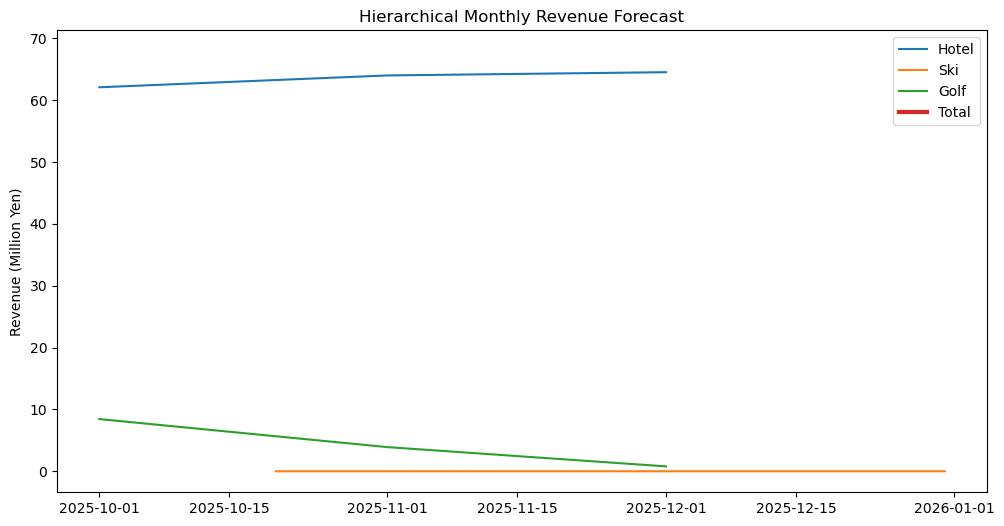

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    hotel_forecast,
    label='Hotel'
)

plt.plot(
    ski_forecast,
    label='Ski'
)

plt.plot(
    golf_forecast,
    label='Golf'
)

plt.plot(
    total_forecast,
    label='Total',
    linewidth=3
)

plt.title(
    'Hierarchical Monthly Revenue Forecast'
)

plt.ylabel(
    'Revenue (Million Yen)'
)

plt.legend()

plt.show()

E. MODEL evaluation and comparison:

   1. Model Evaluation Results
   2. Actual vs Forecast Revenue

  1. Model Evaluation Results

In [81]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Train model
model_es = ExponentialSmoothing(
    train['Revenue'],
    trend='add',
    seasonal=None
)

fit_es = model_es.fit()

# Forecast
forecast_es = fit_es.forecast(len(y_test))

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [82]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

# Evaluation Metrics
mae_ma = mean_absolute_error(y_test, forecast_ma)
rmse_ma = np.sqrt(mean_squared_error(y_test, forecast_ma))

mae_es = mean_absolute_error(y_test, forecast_es)
rmse_es = np.sqrt(mean_squared_error(y_test, forecast_es))

mae_arima = mean_absolute_error(y_test, arima_pred)
rmse_arima = np.sqrt(mean_squared_error(y_test, arima_pred))

mae_lr = mean_absolute_error(y_test, lr_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))

# Comparison Table
results = pd.DataFrame({
    'Model': [
        'Moving Average',
        'Exponential Smoothing',
        'ARIMA',
        'Regression'
    ],
    
    'MAE': [
        mae_ma,
        mae_es,
        mae_arima,
        mae_lr
    ],
    
    'RMSE': [
        rmse_ma,
        rmse_es,
        rmse_arima,
        rmse_lr
    ]
})

# Formatting
results[['MAE', 'RMSE']] = results[['MAE', 'RMSE']].round(2)

# Sort by performance
results = results.sort_values(by='RMSE')

print(results)

                   Model         MAE        RMSE
3             Regression  1532132.51  2765574.49
2                  ARIMA  3721791.73  6447192.97
0         Moving Average  3725199.76  6453614.35
1  Exponential Smoothing  3911751.46  6647333.48


2. Actual vs Forecast Revenue

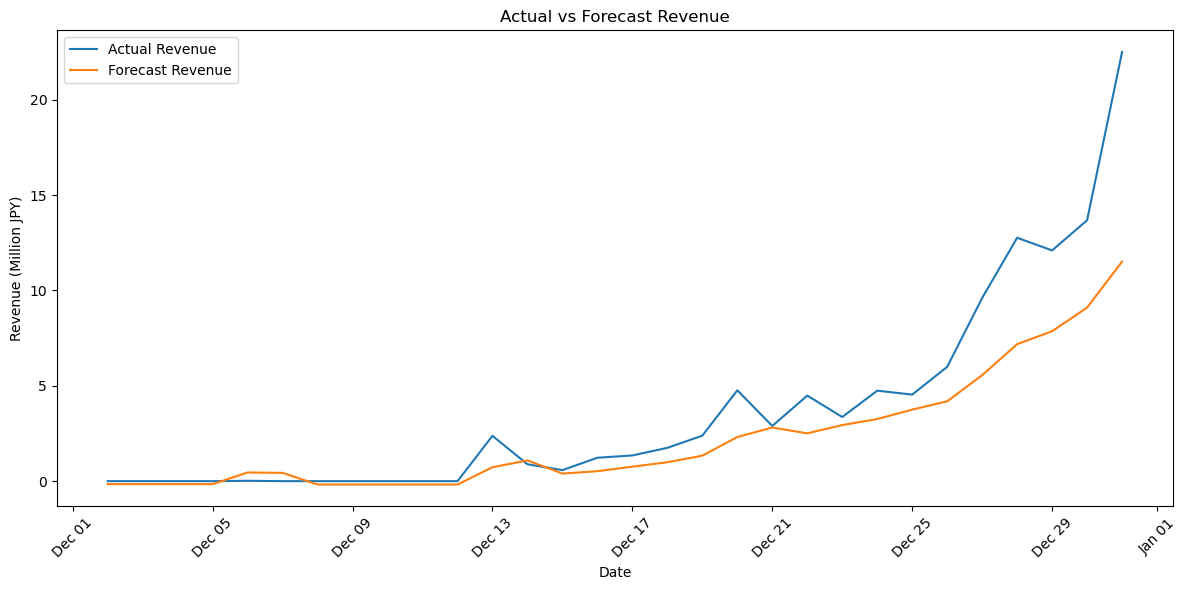

In [83]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convert to million JPY
actual_million = y_test / 1_000_000
pred_million = lr_pred / 1_000_000

plt.figure(figsize=(12,6))

# Actual Revenue
plt.plot(
    y_test.index,
    actual_million,
    label='Actual Revenue'
)

# Forecast Revenue
plt.plot(
    y_test.index,
    pred_million,
    label='Forecast Revenue'
)

plt.title('Actual vs Forecast Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue (Million JPY)')

# Format x-axis as Dec 01, Dec 05, etc.
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter('%b %d')
)

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

F. VISUALIZATION:

    1. Department Revenue Contribution
    2. Seasonal Revenue Patterns by Department
    3. Revenue Trend and Smoothing

In [84]:
department_summary = monthly_df.groupby(
    'Department'
)['Revenue'].sum()

1. Department Revenue Contribution

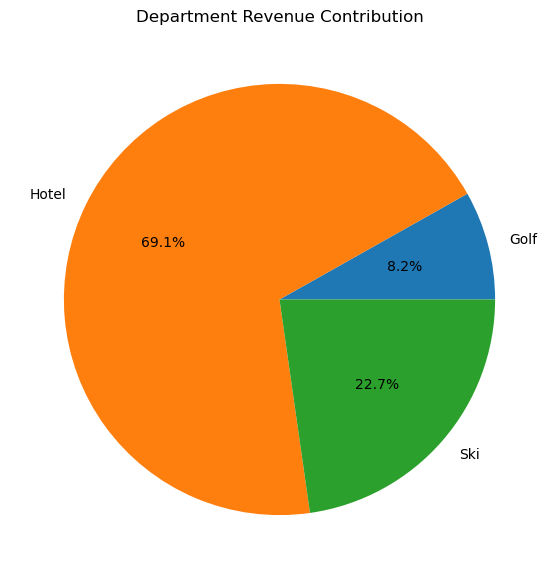

In [85]:
department_summary.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7),
    title='Department Revenue Contribution'
)

plt.ylabel('')

plt.show()

 2. Seasonal Revenue Patterns by Department

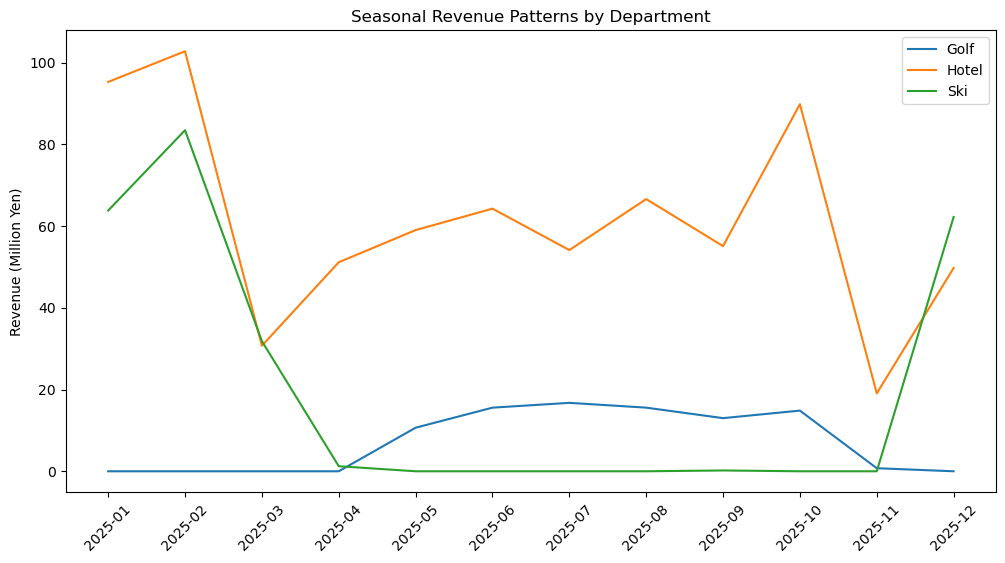

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for dept in monthly_df['Department'].unique():
    
    temp = monthly_df[
        monthly_df['Department'] == dept
    ]
    
    plt.plot(
        temp['Month_Date'].astype(str),
        temp['Revenue'],
        label=dept
    )

plt.title(
    'Seasonal Revenue Patterns by Department'
)

plt.ylabel(
    'Revenue (Million Yen)'
)

plt.xticks(rotation=45)

plt.legend()

plt.show()

3. Revenue Trend and Smoothing

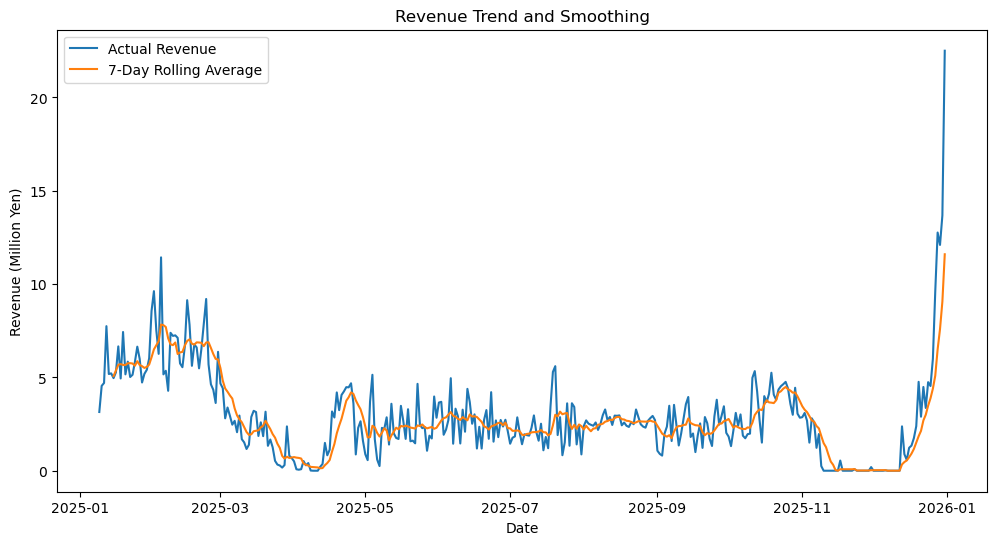

In [87]:
import matplotlib.pyplot as plt

# Convert revenue to million yen
actual_million = daily_total['Revenue'] / 1_000_000
rolling_million = daily_total['Rolling_7'] / 1_000_000

plt.figure(figsize=(12,6))

plt.plot(
    daily_total.index,
    actual_million,
    label='Actual Revenue'
)

plt.plot(
    daily_total.index,
    rolling_million,
    label='7-Day Rolling Average'
)

plt.title('Revenue Trend and Smoothing')

plt.xlabel('Date')

plt.ylabel('Revenue (Million Yen)')

plt.legend()

plt.show()

G. Business Insights and Recommendation

 a. Revenue Behavior

- Ski revenue dominates winter demand  
- Hotel revenue is stable baseline income  
- Golf revenue is highly volatile  
- Weekend demand is slightly higher  


b. Forecast Model Insight

-Regression achieved the best forecasting performance with the lowest error values.
-ARIMA captured revenue trends better than baseline forecasting models.
-Moving Average provided stable baseline forecasting performance.
-Exponential Smoothing showed comparatively higher forecasting errors.

 c. Operational Actions

- Increase staffing during winter peak season  
- Optimize hotel occupancy year-round  
- Apply dynamic pricing during peak demand weeks  
- Adjust golf operations flexibly based on demand  


d. Risks

- Weather not included in model  
- External shocks may reduce accuracy  